<div align='center'>

# 🌾 Lecture #6 — Python for ML Research
## Data Preprocessing: From Raw Agricultural Data to ML-Ready Pipeline

**Instructor:** Md. Samiul Islam &nbsp;|&nbsp; **Institution:** Skill Morph Research Lab  
**Dataset:** [Agriculture & Farming Dataset — Kaggle](https://www.kaggle.com/datasets/bhadramohit/agriculture-and-farming-dataset)  
**Records:** 50 farms &nbsp;|&nbsp; **Features:** 9 (5 numeric, 4 categorical) &nbsp;|&nbsp; **Target:** Yield (tons)

</div>

---

### 📑 Table of Contents

| # | Title |
|---|-------|
| 1 | Library Setup |
| 2 | Data Import |
| 3 | Data Exploration |
| 4 | Inject Missing Values (Teaching Utility) |
| 5 | Data Cleaning — Missing Values, Duplicates |
| 6 | Visualization — Distributions & Correlation |
| 7 | Encoding Categorical Data |
| 8 | Scaling & Normalization |
| 9 | Train-Test Split |
| 10 | Activity — Full Preprocessing Pipeline |
| 11 | Summary |

## Cell 1 | Library Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')

## Cell 2 | Data Import

In [10]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets/agriculture_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters)
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69


## Cell 3 | Data Exploration

In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Farm_ID                    50 non-null     object 
 1   Crop_Type                  50 non-null     object 
 2   Farm_Area(acres)           50 non-null     float64
 3   Irrigation_Type            50 non-null     object 
 4   Fertilizer_Used(tons)      50 non-null     float64
 5   Pesticide_Used(kg)         50 non-null     float64
 6   Yield(tons)                50 non-null     float64
 7   Soil_Type                  50 non-null     object 
 8   Season                     50 non-null     object 
 9   Water_Usage(cubic meters)  50 non-null     float64
dtypes: float64(5), object(5)
memory usage: 4.0+ KB


,Farm_Area(acres),Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Water_Usage(cubic meters)
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,254.963800,4.905400,2.398000,27.059200,56724.295600
std,139.417782,2.732689,1.438613,13.345789,27264.992053
min,12.500000,0.500000,0.140000,3.860000,5869.750000
25%,135.710000,2.437500,0.972500,16.190000,37818.152500
50%,281.980000,5.045000,2.330000,28.970000,54097.075000
75%,368.107500,6.885000,3.417500,37.860000,82240.032500
max,483.880000,9.960000,4.990000,48.020000,94754.730000


## Cell 4 | Inject Missing Values

The original Kaggle dataset has **no missing values**.  
We **artificially inject** NaNs to practice `fillna()`.

| Column | # NaN
|--------|-------
| Farm_Area(acres) | 5
| Fertilizer_Used(tons) | 4
| Soil_Type | 3
| Water_Usage(cubic meters) | 3

In [12]:


# Confirm zero NaNs
print(df.isnull().sum().sum())   # should print 0



0


In [13]:
# Now inject safely
np.random.seed(42)
for col, n in inject.items():
    idx = np.random.choice(df.index, size=n, replace=False)
    df.loc[idx, col] = np.nan

# Verify
df.isnull().sum()[df.isnull().sum() > 0]

,0
Farm_Area(acres),5
Fertilizer_Used(tons),4
Soil_Type,3
Water_Usage(cubic meters),3


## Cell 5 | Data Cleaning — Missing Values, Duplicates

### 5a — Fill Missing Values

In [15]:
# Numeric → median; Categorical → mode (most frequent)
df['Farm_Area(acres)'].fillna(df['Farm_Area(acres)'].median(), inplace=True)
df['Fertilizer_Used(tons)'].fillna(df['Fertilizer_Used(tons)'].mean(), inplace=True)
df['Water_Usage(cubic meters)'].fillna(df['Water_Usage(cubic meters)'].median(), inplace=True)
df['Soil_Type'].fillna(df['Soil_Type'].mode()[0], inplace=True)

df.isnull().sum().sum()  # should be 0

np.int64(0)

### 5b — Duplicates

In [16]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (50, 10)


## Cell 6 | Visualization — Distributions & Correlation

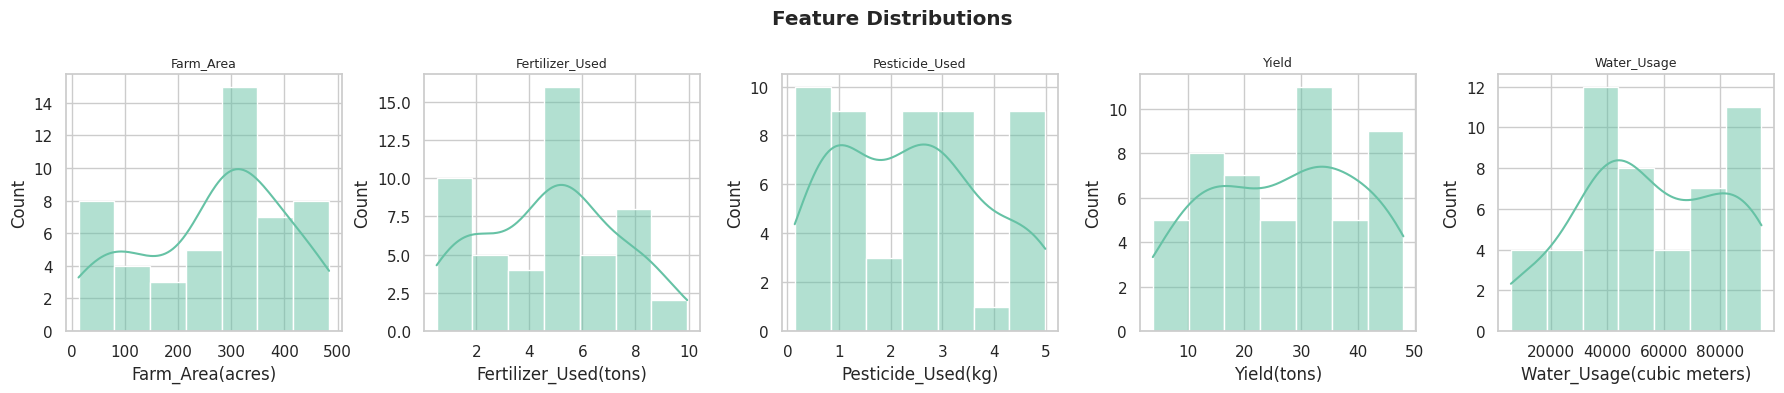

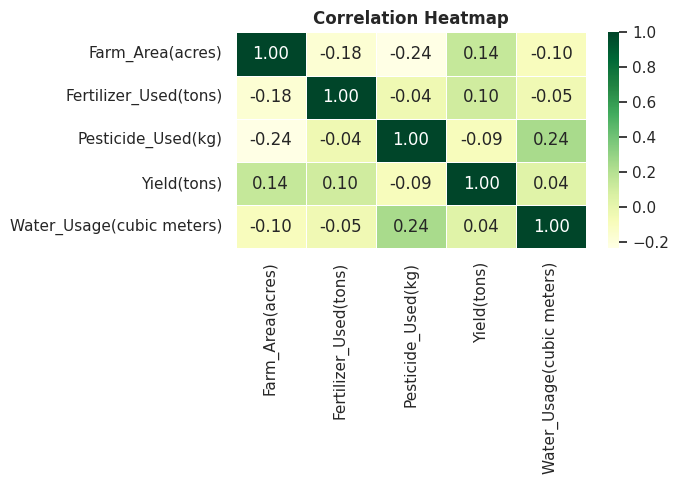

In [17]:
num_cols = ['Farm_Area(acres)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)',
            'Yield(tons)', 'Water_Usage(cubic meters)']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col.split('(')[0], fontsize=9)
plt.suptitle('Feature Distributions', fontweight='bold'); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold'); plt.tight_layout(); plt.show()

## Cell 7 | Encoding Categorical Data

In [21]:
cat_cols = ['Crop_Type', 'Irrigation_Type', 'Soil_Type', 'Season']
df_enc = df.drop(columns=['Farm_ID']).copy()

# Label Encoding — best for tree-based models
le = LabelEncoder()
df_enc['Season_LE'] = le.fit_transform(df_enc['Season'])
df_enc.head(10)


,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters),Season_LE
0,Cotton,329.40,Sprinkler,8.140000,2.21,14.44,Loamy,Kharif,76648.20,0
1,Carrot,18.67,Manual,4.770000,4.36,42.91,Clay,Kharif,68725.54,0
2,Sugarcane,306.03,Flood,4.774565,0.56,33.44,Silty,Kharif,75538.56,0
3,Tomato,380.21,Rain-fed,3.320000,4.35,34.08,Silty,Zaid,45401.23,2
4,Tomato,135.56,Sprinkler,8.330000,4.48,43.28,Clay,Zaid,93718.69,2
5,Sugarcane,12.50,Sprinkler,6.420000,2.25,38.18,Clay,Zaid,46487.98,2
6,Soybean,360.06,Drip,1.830000,2.37,44.93,Sandy,Rabi,40583.57,1
7,Rice,464.60,Drip,5.180000,0.91,4.23,Silty,Kharif,9392.38,0
8,Maize,389.37,Drip,0.570000,4.93,3.86,Peaty,Rabi,60202.14,1
9,Soybean,184.37,Drip,2.180000,2.67,17.25,Sandy,Kharif,90922.15,0


In [20]:
# One-Hot Encoding — best for linear / neural models
df_ohe = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)
df_ohe.head(3)

,Farm_Area(acres),Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Water_Usage(cubic meters),Season_LE,Crop_Type_Carrot,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Potato,...,Irrigation_Type_Flood,Irrigation_Type_Manual,Irrigation_Type_Rain-fed,Irrigation_Type_Sprinkler,Soil_Type_Loamy,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silty,Season_Rabi,Season_Zaid
0,329.40,8.140000,2.21,14.44,76648.20,0,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False
1,18.67,4.770000,4.36,42.91,68725.54,0,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,306.03,4.774565,0.56,33.44,75538.56,0,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False


## Cell 8 | Scaling & Normalization

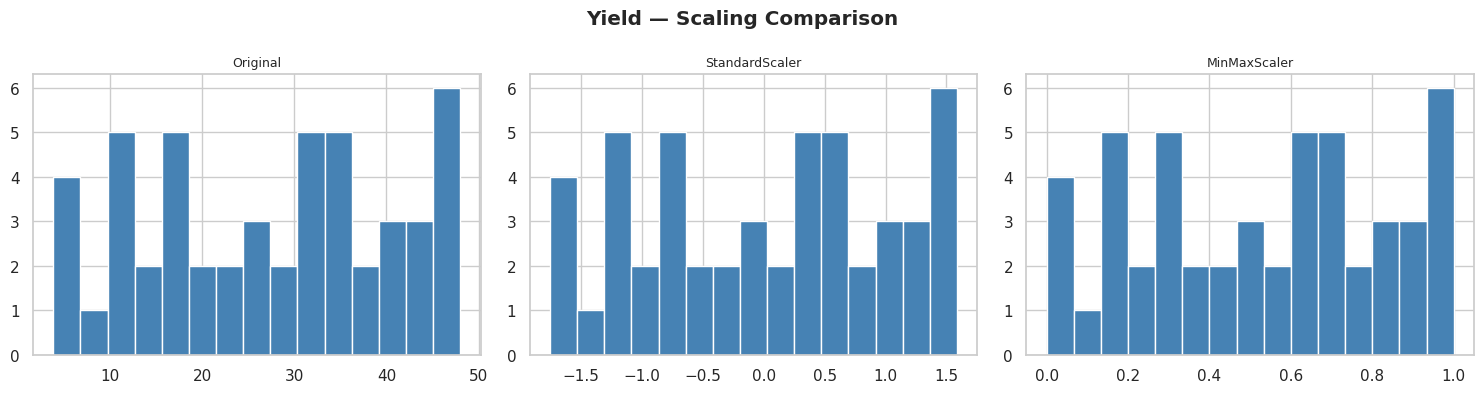

In [22]:
X_num = df[num_cols].copy()
yield_idx = num_cols.index('Yield(tons)')

scalers = {
    'Original'       : X_num['Yield(tons)'],
    'StandardScaler'  : pd.Series(StandardScaler().fit_transform(X_num)[:, yield_idx]),
    'MinMaxScaler'    : pd.Series(MinMaxScaler().fit_transform(X_num)[:, yield_idx])
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=15, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=9)
plt.suptitle('Yield — Scaling Comparison', fontweight='bold'); plt.tight_layout(); plt.show()

## Cell 9 | Train-Test Split

X_train: (40, 23)  |  X_test: (10, 23)


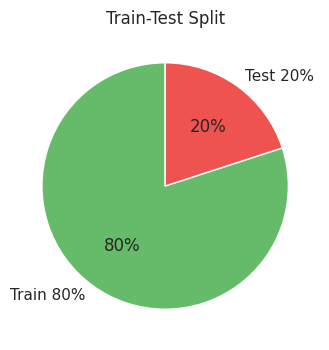

In [ ]:
X = df_ohe.drop(columns=['Yield(tons)', 'Season_LE'], errors='ignore')
y = df['Yield(tons)'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

plt.figure(figsize=(4, 4))
plt.pie([len(X_train), len(X_test)], labels=['Train 80%', 'Test 20%'],
        colors=['#66BB6A','#EF5350'], autopct='%1.0f%%', startangle=90)
plt.title('Train-Test Split'); plt.show()

## Cell 10 | Activity — Full Preprocessing Pipeline

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/datasets/agriculture_dataset.csv')

# Inject NaNs (same seed for reproducibility)
np.random.seed(42)
for col, n in {'Farm_Area(acres)':5, 'Fertilizer_Used(tons)':4,
               'Soil_Type':3, 'Water_Usage(cubic meters)':3}.items():
    data.loc[np.random.choice(data.index, n, replace=False), col] = np.nan

# Fill missing
data['Farm_Area(acres)'].fillna(data['Farm_Area(acres)'].median(), inplace=True)
data['Fertilizer_Used(tons)'].fillna(data['Fertilizer_Used(tons)'].mean(), inplace=True)
data['Water_Usage(cubic meters)'].fillna(data['Water_Usage(cubic meters)'].median(), inplace=True)
data['Soil_Type'].fillna(data['Soil_Type'].mode()[0], inplace=True)

# Clean
data.drop_duplicates(inplace=True)
data.drop(columns=['Farm_ID'], inplace=True)
for col in data.select_dtypes(include=np.number).columns:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    data = data[data[col].between(q1 - 1.5*iqr, q3 + 1.5*iqr)]

# Encode → Split → Scale
data = pd.get_dummies(data, columns=['Crop_Type','Irrigation_Type','Soil_Type','Season'], drop_first=True)
X = data.drop(columns=['Yield(tons)']).values
y = data['Yield(tons)'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Pipeline complete → X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Pipeline complete → X_train: (40, 23)  |  X_test: (10, 23)


## Cell 11 | Summary

| Step | Method | Key Rule |
|------|--------|----------|
| Import | `pd.read_csv()` | Load from Drive path |
| Explore | `.info()`, `.describe()` | Understand before touching |
| Missing Values | `.fillna(median/mean/mode)` | Median for skewed, mean for normal, mode for categorical |
| Duplicates | `.drop_duplicates()` | Always remove first |
| Outliers | IQR method | Boxplot to confirm |
| Label Encoding | `LabelEncoder` | Tree-based models |
| One-Hot Encoding | `pd.get_dummies()` | Linear / Neural models |
| StandardScaler | Z-score | SVM, PCA, LogReg |
| MinMaxScaler | [0, 1] range | Neural Networks, KNN |
| RobustScaler | IQR-based | Outlier-heavy data |
| Split | `train_test_split` | Fit scaler on **train only** |

---

### 🚀 Next — Lecture #6: Feature Engineering & Selection
- Creating new features from existing ones  
- Filter, Wrapper, Embedded selection methods  
- PCA, t-SNE, UMAP for dimensionality reduction

<div align='center'>

> *"Clean data is not an accident — it is the result of intentional effort."*  
> **— Skill Morph Research Lab**

</div>